In [ ]:
!pip install scikit-learn

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, ARDRegression, GammaRegressor, HuberRegressor, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

df = pd.read_csv("house-clean.csv")
X = df[["SqFt", 'Bedrooms','Bathrooms']]
Y = df['Price']

# df = pd.read_csv("healthcare_dataset.csv")
# X = df[["Age","Billing Amount"]]
# Y = df["TotalDays"]

#Create instance of Linear Regression
# model = LinearRegression()
# model = ARDRegression()
# model = GammaRegressor()
# model = HuberRegressor()
model = Lasso()

#Use Data Frame Columns for X, Y axis and also for Test and Train values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

predictions

print("Mean Squared Error : ",mean_squared_error(Y_test, predictions))
print("Mean Absolute Error : ", mean_absolute_error(Y_test, predictions))
print("RMSE : ",root_mean_squared_error(Y_test, predictions))
r2 = r2_score(Y_test, predictions)
print("R2 : ",r2)

Mean Squared Error :  320154161.5862679
Mean Absolute Error :  14768.295821280712
RMSE :  17892.852248489282
R2 :  0.45681241222392466


In [ ]:
#create a python application that uses Supervised Learning to predict the price of a house based on its features such as size, number of bedrooms, and location.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Load the clean dataset
data = pd.read_csv('house_prices.csv')

#Label encoding for location feature
le = LabelEncoder()
data['city'] = le.fit_transform(data['city'])

# Update features to include the encoded location
X = data[['sqft_living', 'bedrooms', 'yr_built', 'city']]
y = data['price']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

print(y_pred)

#predict the price of a house with 2000 sqft, 3 bedrooms, built in 1990, and located in 'Redmond'
new_house = np.array([[2000, 3, 1990, le.transform(['Redmond'])[0]]])
predicted_price = model.predict(new_house)
print(f'The predicted price of the house is: ${predicted_price[0]:,.2f}')

#evaluation metrics of the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

[523037.18403429 425822.39116033 511797.02728093 ... 505600.78445206
 591881.96108419 739729.90498117]
The predicted price of the house is: $514,004.86
Mean Squared Error: 86321155833.75
R-squared: 0.48


c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Computing regularization path using the lasso...
Computing regularization path using the positive lasso...
Computing regularization path using the LARS...
Computing regularization path using the positive LARS...
Computing regularization path using the elastic net...
Computing regularization path using the positive elastic net...


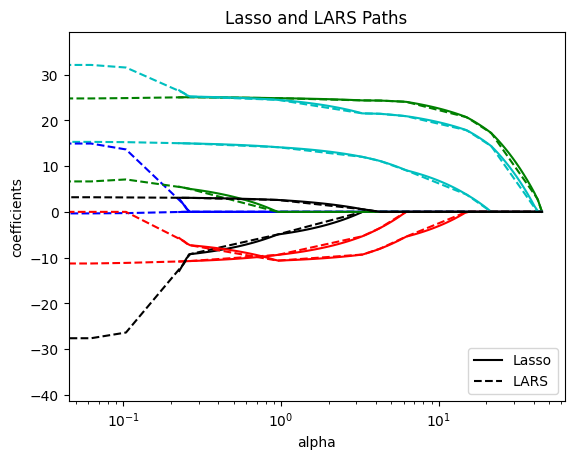

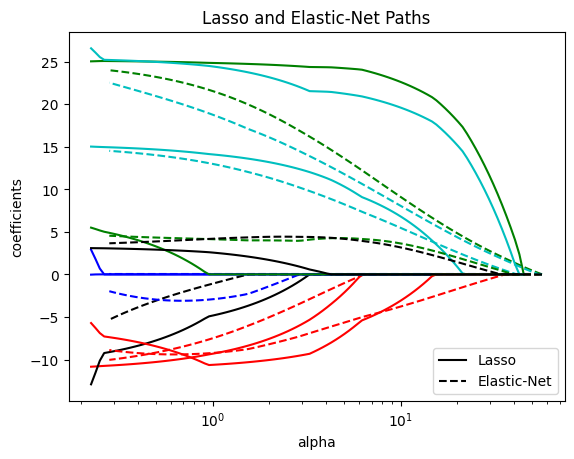

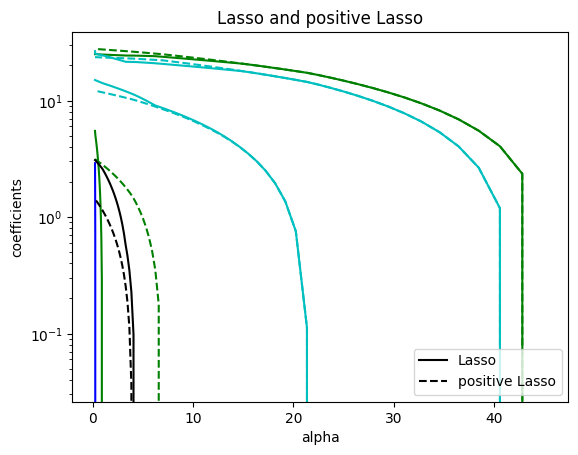

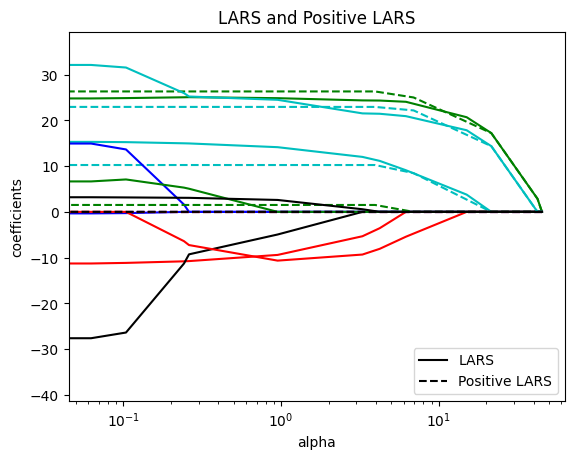

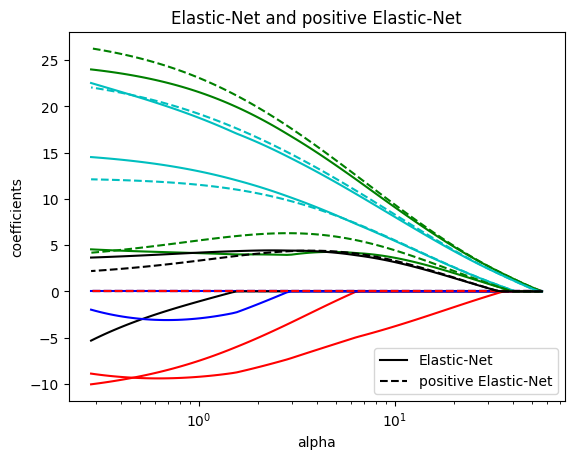

In [6]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

from itertools import cycle

import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import enet_path, lars_path, lasso_path

X, y = load_diabetes(return_X_y=True)
X /= X.std(axis=0)  # Standardize data (easier to set the l1_ratio parameter)

# Compute paths

eps = 5e-3  # the smaller it is the longer is the path

print("Computing regularization path using the lasso...")
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=eps)

print("Computing regularization path using the positive lasso...")
alphas_positive_lasso, coefs_positive_lasso, _ = lasso_path(
    X, y, eps=eps, positive=True
)

print("Computing regularization path using the LARS...")
alphas_lars, _, coefs_lars = lars_path(X, y, method="lasso")

print("Computing regularization path using the positive LARS...")
alphas_positive_lars, _, coefs_positive_lars = lars_path(
    X, y, method="lasso", positive=True
)

print("Computing regularization path using the elastic net...")
alphas_enet, coefs_enet, _ = enet_path(X, y, eps=eps, l1_ratio=0.8)

print("Computing regularization path using the positive elastic net...")
alphas_positive_enet, coefs_positive_enet, _ = enet_path(
    X, y, eps=eps, l1_ratio=0.8, positive=True
)

# Display results

plt.figure(1)
colors = cycle(["b", "r", "g", "c", "k"])
for coef_lasso, coef_lars, c in zip(coefs_lasso, coefs_lars, colors):
    l1 = plt.semilogx(alphas_lasso, coef_lasso, c=c)
    l2 = plt.semilogx(alphas_lars, coef_lars, linestyle="--", c=c)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Lasso and LARS Paths")
plt.legend((l1[-1], l2[-1]), ("Lasso", "LARS"), loc="lower right")
plt.axis("tight")

plt.figure(2)
colors = cycle(["b", "r", "g", "c", "k"])
for coef_l, coef_e, c in zip(coefs_lasso, coefs_enet, colors):
    l1 = plt.semilogx(alphas_lasso, coef_l, c=c)
    l2 = plt.semilogx(alphas_enet, coef_e, linestyle="--", c=c)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Lasso and Elastic-Net Paths")
plt.legend((l1[-1], l2[-1]), ("Lasso", "Elastic-Net"), loc="lower right")
plt.axis("tight")


plt.figure(3)
for coef_l, coef_pl, c in zip(coefs_lasso, coefs_positive_lasso, colors):
    l1 = plt.semilogy(alphas_lasso, coef_l, c=c)
    l2 = plt.semilogy(alphas_positive_lasso, coef_pl, linestyle="--", c=c)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Lasso and positive Lasso")
plt.legend((l1[-1], l2[-1]), ("Lasso", "positive Lasso"), loc="lower right")
plt.axis("tight")


plt.figure(4)
colors = cycle(["b", "r", "g", "c", "k"])
for coef_lars, coef_positive_lars, c in zip(coefs_lars, coefs_positive_lars, colors):
    l1 = plt.semilogx(alphas_lars, coef_lars, c=c)
    l2 = plt.semilogx(alphas_positive_lars, coef_positive_lars, linestyle="--", c=c)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("LARS and Positive LARS")
plt.legend((l1[-1], l2[-1]), ("LARS", "Positive LARS"), loc="lower right")
plt.axis("tight")

plt.figure(5)
for coef_e, coef_pe, c in zip(coefs_enet, coefs_positive_enet, colors):
    l1 = plt.semilogx(alphas_enet, coef_e, c=c)
    l2 = plt.semilogx(alphas_positive_enet, coef_pe, linestyle="--", c=c)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Elastic-Net and positive Elastic-Net")
plt.legend((l1[-1], l2[-1]), ("Elastic-Net", "positive Elastic-Net"), loc="lower right")
plt.axis("tight")
plt.show()

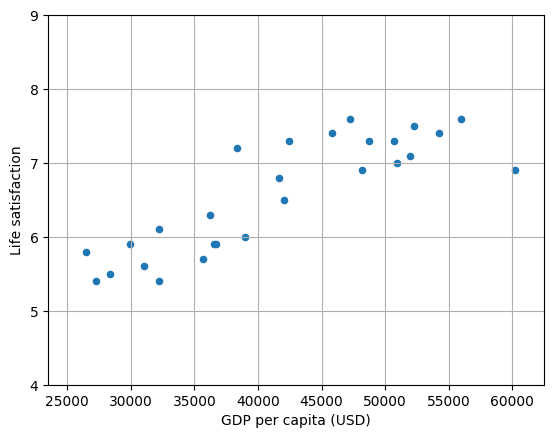

[[6.30165767]]


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

lifesat = pd.read_csv("lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
Y = lifesat[["Life satisfaction"]].values

# Visualize the data
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

model = LinearRegression()
model.fit(X, Y)

X_new = [[37_655.2]]  # Cyprus' GDP per capita in 2020
print(model.predict(X_new)) # outputs [[6.30165767]]